In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.optimize import curve_fit

rng = np.random.default_rng(0)

In [2]:
# --- simulate: 4 groups x 1000 cells, 1000 genes ---
# two axes of variation: a continuous cell type (interpolation between two mean vectors) and depth
muA = rng.lognormal(1.0, 1.0, 1000)                      # cell type endpoint A
muB = rng.lognormal(1.0, 1.0, 1000)                      # cell type endpoint B
t = rng.uniform(0.0, 1.0, 4000)                          # interpolation coefficient per cell
alpha = np.exp(rng.uniform(np.log(0.1), np.log(2.0)))    # global overdispersion, prior on [0.1, 2]
sfs = np.repeat([1.0, 0.7, 0.5, 0.3], 1000)              # size factor per cell

mu = (1 - t)[:, None] * muA + t[:, None] * muB           # cells x genes cell-type mean
m = sfs[:, None] * mu                                    # apply depth scaling
mtx = rng.negative_binomial(1 / alpha, 1 / (1 + alpha * m)).astype(float)  # var = m + alpha*m^2

In [5]:
def identity(a):  # identity
    pass

def normalize_total(a):  # scanpy normalize_total (default median target) + log1p
    sc.pp.normalize_total(a)

def normalize_total_log1p(a):  # scanpy normalize_total (default median target) + log1p
    sc.pp.log1p(a)
    sc.pp.normalize_total(a)

def pflog(a):  # BHGP_2022: shifted log with y0 = 1/(4*alpha), then per-cell centering
    c = curve_fit(lambda v, c: v + c * v**2, a.X.mean(0), a.X.var(0))[0][0]
    sl = np.log(a.X + 1 / (4 * c))
    a.X = sl - sl.mean(1, keepdims=True)

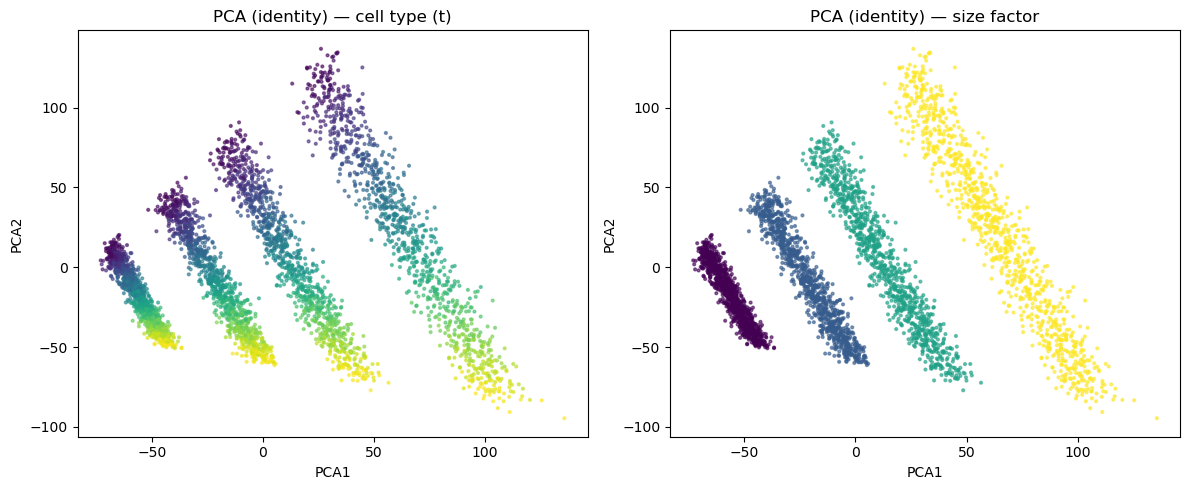

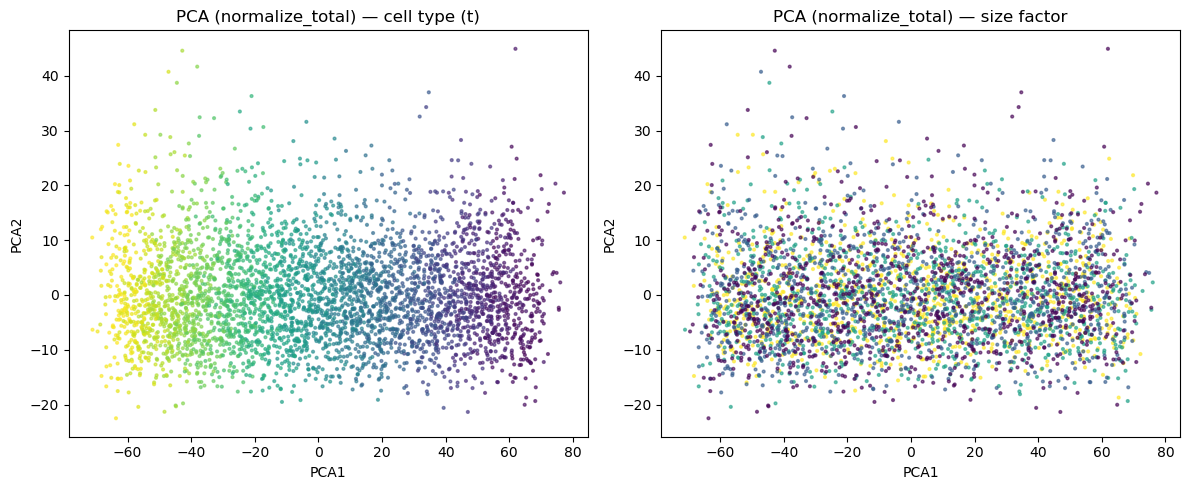

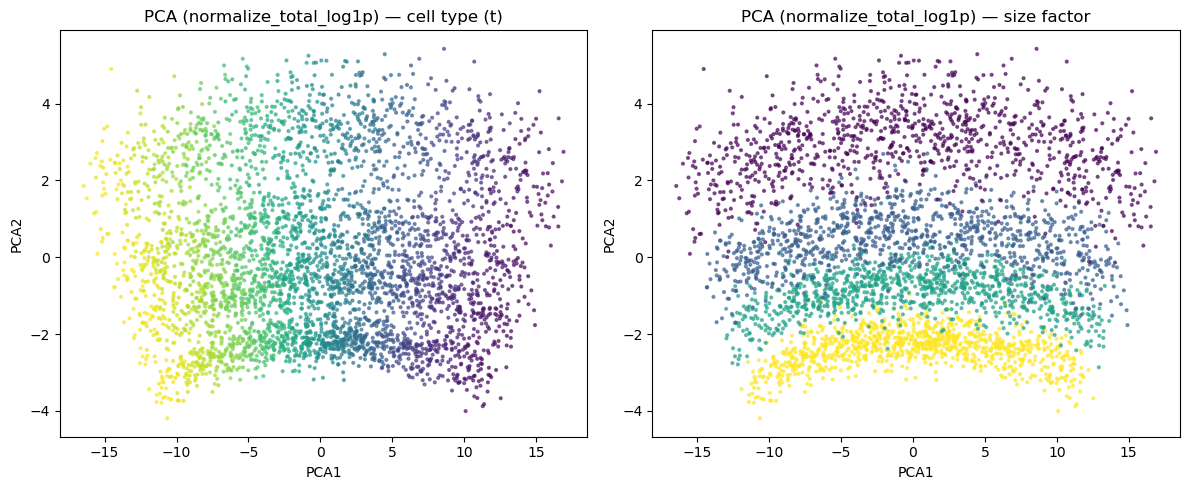

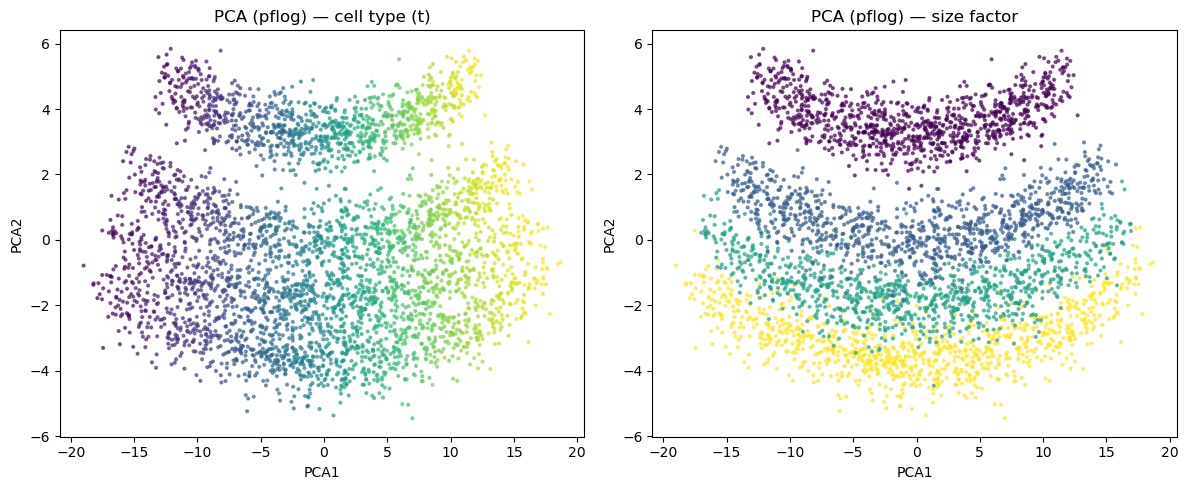

In [7]:
for name, norm in [("identity", identity), ("normalize_total", normalize_total), ("normalize_total_log1p", normalize_total_log1p), ("pflog", pflog)]:
    ad = sc.AnnData(mtx.copy())
    norm(ad)
    sc.pp.pca(ad, n_comps=50)
    pcs = ad.obsm["X_pca"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, c, label in [(axes[0], t, "cell type (t)"), (axes[1], sfs, "size factor")]:
        sc_ = ax.scatter(pcs[:, 0], pcs[:, 1], c=c, cmap="viridis", s=4, alpha=0.6)
        ax.set(title=f"PCA ({name}) — {label}", xlabel="PCA1", ylabel="PCA2")
    fig.tight_layout()
    plt.show()

When only using total count normalization, we see perfect mixing between different size factors. Applying log1p to it, or applying pflog on raw counts shows size factor to be correlated with PC2.